# Part 2 � Traditional NLP Pipeline
In this notebook, we build a classical machine learning pipeline for sentiment analysis.

We will cover:
1. **Text Preprocessing**: Cleaning up the raw movie reviews so our algorithms can understand them.
2. **Feature Extraction**: Converting the cleaned words into numbers using TF-IDF.
3. **Model Training**: Training three different traditional ML algorithms: Logistic Regression, Naive Bayes, and SVM.
4. **Evaluation**: Comparing the accuracy and other metrics of the three models to see which one performs best.

In [11]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load the data
print("Loading data...")
train_df = pd.read_csv('../data/imdb_train.csv')
test_df = pd.read_csv('../data/imdb_test.csv')

X_train_raw = train_df['text']
y_train = train_df['sentiment'].map({"Negative": 0, "Positive": 1})

X_test_raw = test_df['text']
y_test = test_df['sentiment'].map({"Negative": 0, "Positive": 1})

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\padol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\padol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\padol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading data...


## Step 1 Text Preprocessing
Traditional machine learning algorithms are easily confused by messy text. We clean the movie reviews to make the patterns clearer:

* **Lowercasing**: Converts everything to small letters. To a computer, "Terrible" and "terrible" look like two completely different words unless we lowercase them.
* **Removing Punctuation**: We strip out characters like `!`, `?`, and `,` because standard traditional models don't easily extract sentiment from punctuation.
* **Tokenization**: We chop the long review sentence into a list of single words (tokens). Example: `"I love it"` becomes `["i", "love", "it"]`.
* **Removing Stop Words**: We filter out "filler" words like "the", "is", "and", "a". These words appear in both positive and negative reviews, so they don't help the model learn anything useful.

In [12]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()
    # 2. Removing punctuation (keep only lowercase alphabet characters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenization
    tokens = word_tokenize(text)
    # 4. Removing stop words
    clean_tokens = [word for word in tokens if word not in stop_words]
    # Join back into a single string for the vectorizer
    return ' '.join(clean_tokens)

print("Preprocessing training data (this will take a couple of minutes)...")
X_train_clean = X_train_raw.apply(preprocess_text)
print("Preprocessing testing data...")
X_test_clean = X_test_raw.apply(preprocess_text)

print("\nBefore:", X_train_raw.iloc[0][:100])
print("After :", X_train_clean.iloc[0][:100])

Preprocessing training data (this will take a couple of minutes)...
Preprocessing testing data...

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w
After : rented curiousyellow video store controversy surrounded first released also heard first seized us cu


## Step 2 Feature Extraction (TF-IDF Vectorization)
Algorithms only do math; they can't read text. We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to turn our cleaned words into numbers.

* **TF (Term Frequency)**: Counts how many times a word appears in a specific review.
* **IDF (Inverse Document Frequency)**: Lowers the score of words that show up in *every* review (like "movie" or "film") and boosts the score of words that are rare but meaningful (like "masterpiece" or "atrocious").

**Result**: Every review becomes a row of numbers, and each word in our vocabulary becomes a column.

In [13]:
# Initialize the vectorizer (we limit features to 10,000 for memory efficiency)
tfidf = TfidfVectorizer(max_features=10000)

print("Vectorizing data...")
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("Shape of TF-IDF matrix (Train):", X_train_tfidf.shape)

Vectorizing data...
Shape of TF-IDF matrix (Train): (25000, 10000)


## Step 3 Train Traditional Models
We will train three different algorithms to see how they perform and compare their accuracy:

1. **Logistic Regression**: 
   - *How it works*: It looks at the TF-IDF numbers and calculates the mathematical probability of a review being Positive or Negative. It essentially learns a "weight" for each word (e.g., "amazing" gets a positive weight, "boring" gets negative).

2. **Naive Bayes (MultinomialNB)**:
   - *How it works*: It uses Bayes' Theorem to calculate probability. It counts how often a word appears in positive vs negative reviews in the training data, and multiplies those probabilities together for new reviews. It's famous for being a great baseline for text classification.

3. **SVM (Support Vector Machine - LinearSVC)**:
   - *How it works*: It visualizes the reviews as data points in space and tries to draw the widest possible "street" or boundary line that perfectly separates the positive reviews from the negative reviews.

In [14]:
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)

print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("Training SVM (LinearSVC)...")
svm_model = LinearSVC(max_iter=2000, dual=False)
svm_model.fit(X_train_tfidf, y_train)

print("\nAll models trained successfully!")

# Save the models and vectorizer
os.makedirs('../models', exist_ok=True)
joblib.dump(log_reg, '../models/logistic_regression_model.pkl')
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
joblib.dump(svm_model, '../models/svm_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("Models saved to the 'models/' directory.")

Training Logistic Regression...
Training Naive Bayes...
Training SVM (LinearSVC)...

All models trained successfully!
Models saved to the 'models/' directory.


## Step 4 Evaluation
We test the model on the 25,000 completely new reviews (the test set) it has never seen before to see how well it learned.

**Metrics Explained:**
* **Accuracy**: Out of all 25,000 reviews, what percentage did the model guess correctly?
* **Precision**: "When the model said a review was Positive, how often was it actually positive?" (Minimizes false positives).
* **Recall**: "Out of all the truly Positive reviews in the dataset, how many did the model successfully find?" (Minimizes false negatives).
* **F1-Score**: A blended average of Precision and Recall. It gives a better sense of overall balance.
* **Confusion Matrix**: A 2x2 grid (heatmap chart) that visualizes exactly where the model got confused (e.g., how many negative reviews it accidentally labeled as positive).

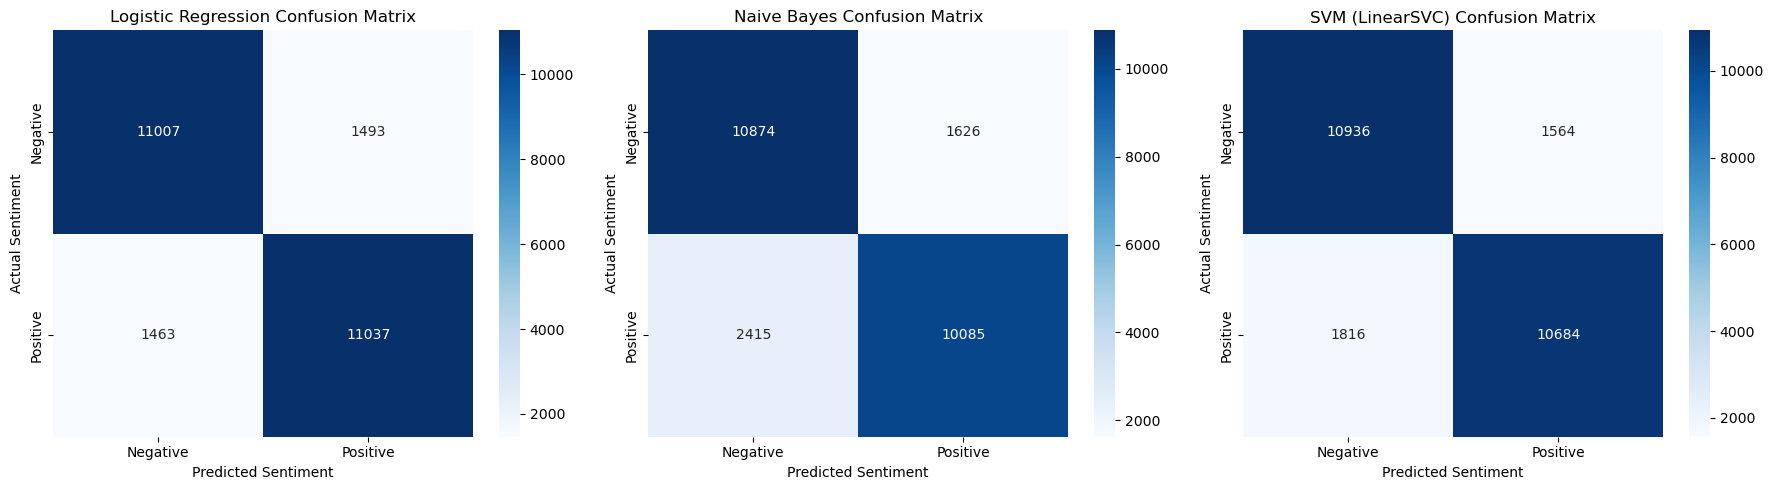


--- Model Comparison (Sorted by Accuracy) ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.88176,0.880846,0.88296,0.881902
SVM (LinearSVC),0.86480,0.872306,0.85472,0.863423
Naive Bayes,0.83836,0.861156,0.80680,0.833092


In [16]:
from IPython.display import display

models = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb_model,
    "SVM (LinearSVC)": svm_model
}

results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
os.makedirs('../reports', exist_ok=True)

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_ylabel('Actual Sentiment')
    axes[i].set_xlabel('Predicted Sentiment')

plt.tight_layout()
plt.savefig('../reports/traditional_confusion_matrices.png')
plt.show()

# Display results in a nice table sorted by Accuracy
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\n--- Model Comparison (Sorted by Accuracy) ---")
display(results_df)